# 6-dot GDS 生成与可视化（基于 `six_dot_generator_SG1_20260312.py`）

这个 Notebook 用来：
1. 调用 `create_6qd_device_core(...)` 生成 GDS `cell`
2. 使用脚本内置的 `plot_gds(cell, ...)` 进行 matplotlib 可视化
3. （可选）保存生成的 GDS 到 `GDS_Drawer/6-dot/output_6dot/`


## 0. 环境准备

- 需要依赖：`gdstk`, `numpy`, `matplotlib`
- 如果你的环境里没有 `gdstk`，请先在当前 python 环境安装：

```bash
pip install gdstk
```


In [5]:
import os
import sys

# 确保能 import 同目录下的 six_dot_generator_SG1_20260312.py
this_dir = os.path.abspath(os.path.join(os.getcwd(), "GDS_Drawer", "6-dot"))
if this_dir not in sys.path:
    sys.path.insert(0, this_dir)

print("Notebook cwd:", os.getcwd())
print("Added to sys.path:", this_dir)


Notebook cwd: c:\Users\Administrator\Desktop\Spin_Quantum_Hardware_Simulation\GDS_Drawer\6-dot
Added to sys.path: c:\Users\Administrator\Desktop\Spin_Quantum_Hardware_Simulation\GDS_Drawer\6-dot\GDS_Drawer\6-dot


## 1. 导入生成器

我们直接复用脚本里的：
- `create_6qd_device_core(...)`
- `plot_gds(cell, title=...)`
- `save_gds(lib, filepath)`


In [6]:
from six_dot_generator_SG1_20260312 import (
    create_6qd_device_core,
    plot_gds,
    save_gds,
)

print("Imports OK")


Imports OK


## 2. 参数区（可修改）

下面的参数默认对齐脚本 `__main__` 中的调用。你可以按需修改。

计算中间 S/D 引线延长部分: bend=0.100, extend=0.200
6量子点器件核心已创建:
  - 主阵列量子点: 6 个
  - 传感器阵列量子点: 2 个
  - 总连接点数: 32
connection points: 32
视图范围: X[-1.04, 2.14], Y[-0.70, 1.26]


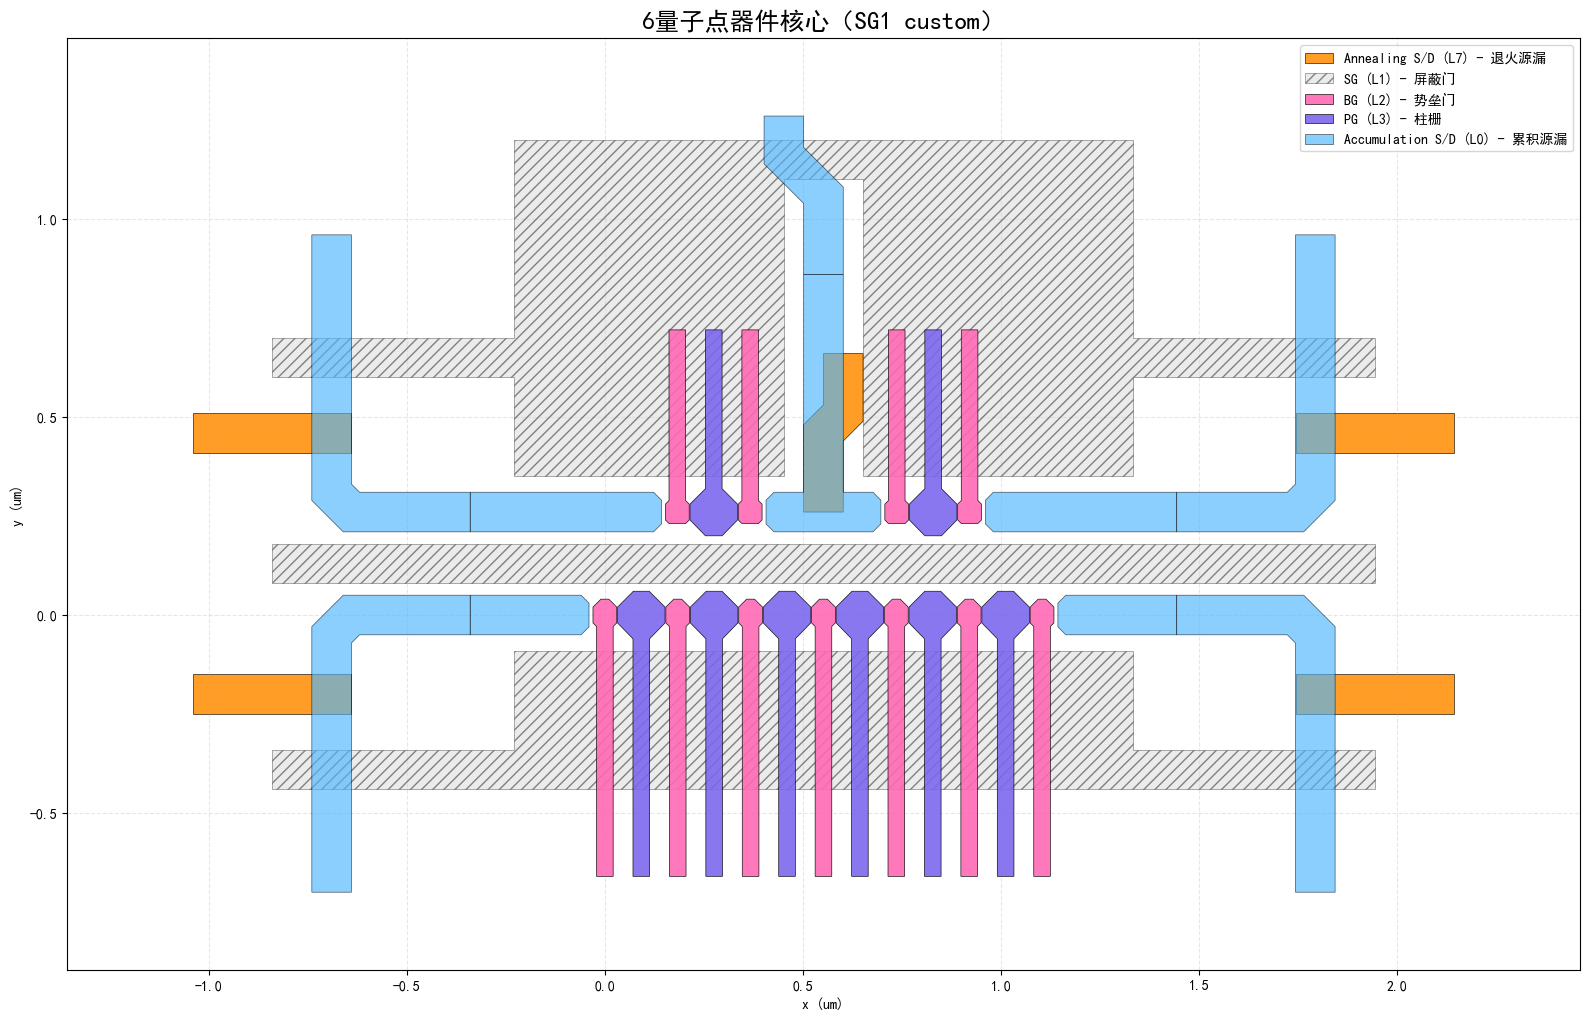

In [7]:
params = dict(
    num_dots=6,
    pg_max_width=0.120,
    pg_vert_side_len=0.040,
    pg_chamfer_h=0.040,
    bg_max_width=0.060,
    bg_vert_side_len=0.040,
    gap_pg_bg=0.002,
    d1_gap=0.020,
    d2_gap=0.020,
    sg_mid_thick=0.100,
    sg_top_thick=0.100,
    sg_bot_thick=0.100,
    
    anneal_sd_enable=True,
    anneal_sd_gap_to_accum=0.50,
    anneal_sd_rect_w=0.10,
    anneal_sd_rect_h=0.40,
    anneal_sd_dx=0.50,
    anneal_sd_dy=0.20,
    anneal_central_set_dx=0.0, # 0.05
    anneal_central_set_dy=0.8,
    anneal_sd_gap_override=False,
    accum_sd_lead_extend_to_anneal=0.20,
    anneal_set_s_enable=True,
    
    lead_width=0.042,
    lead_length_bot=0.6,
    lead_length_top=0.4,
)

lib, cell, points = create_6qd_device_core(**params)

print("connection points:", len(points))
list(points.items())[:5]

plot_gds(cell, title="6量子点器件核心（SG1 custom）")


## 5. 保存 GDS（可选）

默认保存到：`GDS_Drawer/6-dot/output_6dot/`

In [ ]:
out_dir = os.path.join(os.getcwd(), "GDS_Drawer", "6-dot", "output_6dot")
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "6qd_device_core_from_notebook.gds")
save_gds(lib, out_path)

out_path


## 6. （可选）导出 points 为 CSV

便于后续布线/对齐使用。

In [ ]:
import csv

csv_path = os.path.join(out_dir, "connection_points.csv")

with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["name", "x", "y"])
    for k, (x, y) in points.items():
        w.writerow([k, x, y])

csv_path
